Домашнее задание: Решающие деревья, ансамбли и бустинг

Датасет: [Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset) (предсказание, подпишется ли клиент на депозит)

In [82]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset


Первичный анализ данных ( 1 балл)

- Загрузите данные и выполните первичный анализ

- Проведите анализ распределения целевой переменной

- Выявите и обработайте пропущенные значения в данных
- Преобразуй категориальные данные в числовые (LabelEncoder)
- Разделите данные на обучающую и тестовую выборки в соотношении 80/20


In [83]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [84]:
csv_path = None
for fname in os.listdir(path):
    if fname.endswith(".csv"):
        csv_path = os.path.join(path, fname)
        break

print("Используем файл:", csv_path)

Используем файл: /kaggle/input/bank-marketing-dataset/bank.csv


In [85]:
df = pd.read_csv(csv_path)
print("Размер данных:", df.shape)

Размер данных: (11162, 17)


In [86]:
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [87]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


None

In [88]:
display(df.describe())

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [89]:
display(df.describe(include="object"))

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873



Распределение целевой переменной (counts):
deposit
no     5873
yes    5289
Name: count, dtype: int64

Распределение целевой переменной (доля):
deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64


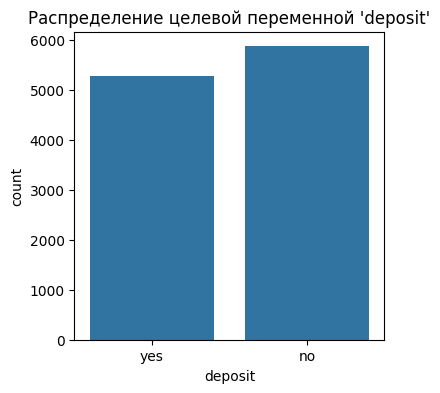

In [90]:
print("\nРаспределение целевой переменной (counts):")
print(df["deposit"].value_counts())

print("\nРаспределение целевой переменной (доля):")
print(df["deposit"].value_counts(normalize=True))

plt.figure(figsize=(4, 4))
sns.countplot(x="deposit", data=df)
plt.title("Распределение целевой переменной 'deposit'")
plt.show()

In [91]:
print("\nЧисло пропусков по столбцам:")
na_counts = df.isna().sum()
print(na_counts[na_counts > 0])


Число пропусков по столбцам:
Series([], dtype: int64)


Пропусков нет.

In [92]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nПосле LabelEncoder:")
display(df.head())


После LabelEncoder:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [93]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  int64
 2   marital    11162 non-null  int64
 3   education  11162 non-null  int64
 4   default    11162 non-null  int64
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  int64
 7   loan       11162 non-null  int64
 8   contact    11162 non-null  int64
 9   day        11162 non-null  int64
 10  month      11162 non-null  int64
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  int64
 16  deposit    11162 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB


None

In [94]:
X = df.drop("deposit", axis=1)
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер X_train:", X_train.shape)
print("Размер X_test :", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test :", y_test.shape)

Размер X_train: (8929, 16)
Размер X_test : (2233, 16)
Размер y_train: (8929,)
Размер y_test : (2233,)


Часть 1: Решающие деревья ( 3 балла)

Постройте решающее дерево для классификации с максимальной глубиной 3. Визуализируйте дерево и ответьте:

- Какие 3 признака оказались самыми важными на верхнем уровне дерева?

- Какой лист содержит наибольшее количество объектов и каково его предсказание?

In [95]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

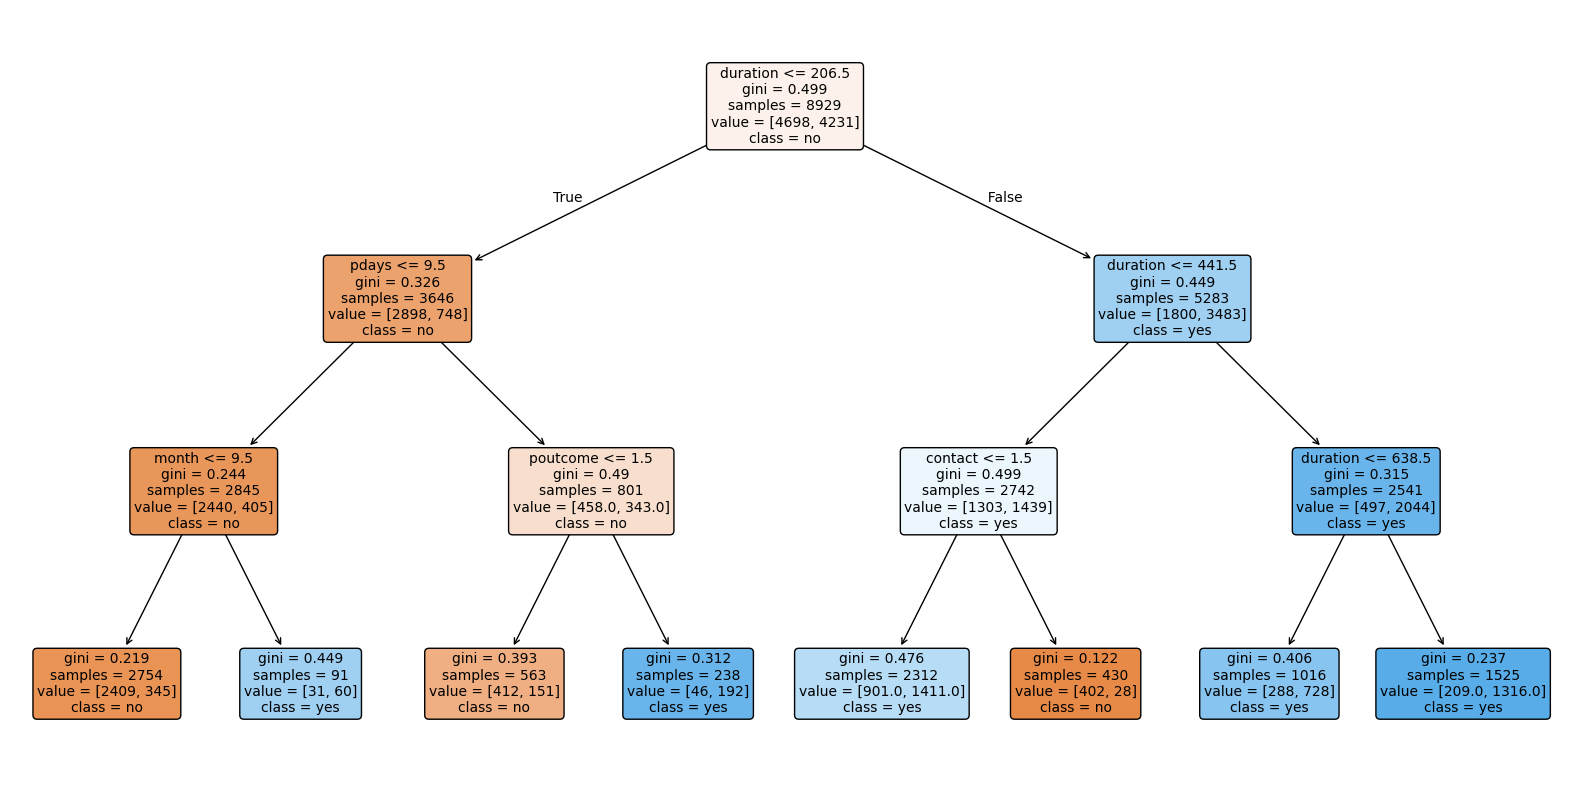

In [96]:
dt_clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    criterion="gini"
)

dt_clf.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_clf,
    feature_names=X_train.columns,
    class_names=label_encoders['deposit'].classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [97]:
tree = dt_clf.tree_

root_id = 0
root_feature = X_train.columns[tree.feature[root_id]]

left_child_id = tree.children_left[root_id]
right_child_id = tree.children_right[root_id]

left_feature = X_train.columns[tree.feature[left_child_id]]
right_feature = X_train.columns[tree.feature[right_child_id]]

top3_features = [root_feature, left_feature, right_feature]
print("Три самых важных признака на верхнем уровне дерева (корень и его дети):")
print(top3_features)

Три самых важных признака на верхнем уровне дерева (корень и его дети):
['duration', 'pdays', 'duration']


In [98]:
n_nodes = tree.node_count
children_left = tree.children_left
children_right = tree.children_right

is_leaf = np.zeros(shape=n_nodes, dtype=bool)
for node_id in range(n_nodes):
    if children_left[node_id] == children_right[node_id]:
        is_leaf[node_id] = True

leaf_ids = np.where(is_leaf)[0]
leaf_samples = tree.n_node_samples[leaf_ids]

max_leaf_id = leaf_ids[np.argmax(leaf_samples)]
max_leaf_n = tree.n_node_samples[max_leaf_id]

class_idx = np.argmax(tree.value[max_leaf_id][0])
class_name = label_encoders['deposit'].inverse_transform([class_idx])[0]

print(f"\nЛист с наибольшим числом объектов:")
print(f"node_id = {max_leaf_id}")
print(f"Количество объектов = {max_leaf_n}")
print(f"Предсказание класса = '{class_name}'")



Лист с наибольшим числом объектов:
node_id = 3
Количество объектов = 2754
Предсказание класса = 'no'


Ответ на вопрос:

1) Три признака на верхнем уровне дерева: корень - duration, левый потомок - pdays, правый потомок - снова duration.
То есть дерево сначала делится по duration, потом по pdays в одной ветви и опять по duration в другой.

2) Лист с наибольшим числом объектов: node_id = 3, содержит 2754 объекта, его предсказание: класс 'no' (клиент не подпишется на депозит).

- Проведите эксперимент с разной глубиной дерева (от 2 до 10). Постройте график:

Ось X: глубина дерева

Ось Y: accuracy на тренировочной и тестовой выборках

In [99]:
from sklearn.metrics import accuracy_score

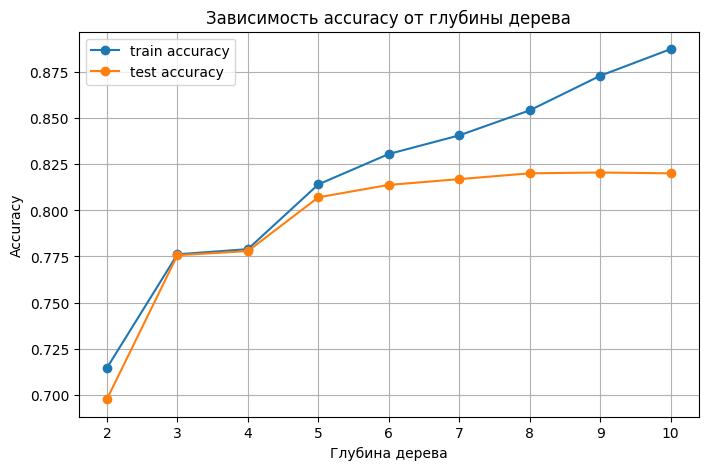

In [100]:
depths = range(2, 11)

train_accs = []
test_accs = []

for d in depths:
    clf = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        criterion="gini"
    )
    clf.fit(X_train, y_train)

    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)

    train_accs.append(accuracy_score(y_train, y_pred_train))
    test_accs.append(accuracy_score(y_test, y_pred_test))


plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, marker="o", label="train accuracy")
plt.plot(depths, test_accs, marker="o", label="test accuracy")
plt.xlabel("Глубина дерева")
plt.ylabel("Accuracy")
plt.title("Зависимость accuracy от глубины дерева")
plt.xticks(list(depths))
plt.grid(True)
plt.legend()
plt.show()

In [101]:
best_depth = depths[np.argmax(test_accs)]
print(f"Лучшая глубина по accuracy на тесте: {best_depth}")

Лучшая глубина по accuracy на тесте: 9


- Объясните, наблюдаете ли вы переобучение. На какой глубине оно начинает проявляться?
- Сравните поведение accuracy на тренировочной и тестовой выборках.

Ответ на вопрос:

1) Да, переобучение видно. До глубины 4–5 train и test accuracy растут почти одинаково. Начиная примерно с глубины 6, train-accuracy продолжает заметно расти, а test-accuracy почти перестаёт улучшаться и выходит на плато около 0.82. При дальнейшем увеличении глубины (7–10) дерево всё лучше подгоняется под обучающую выборку, но качество на тесте почти не растёт - это и есть проявление переобучения.

2) Train accuracy монотонно увеличивается от ~0.71 при глубине 2 до ~0.89 при глубине 10: чем глубже дерево, тем лучше оно запоминает обучающие объекты. Test accuracy сначала растёт довольно резко (2 - 5), затем после глубины ~5–6 выходит на плато и держится около 0.82, почти не выигрывая от дальнейшего усложнения модели. То есть дерево становится всё более сложным и идеально подстраивается под train, но польза для тестовой выборки после глубины ~6 уже минимальна — тичная картина переобучения.

Часть 2: Случайный лес ( 3 балла)

Обучите случайный лес с 100 деревьями. Сравните его производительность с лучшим одиночным деревом из Части 1.

- На сколько процентов улучшилась accuracy?

- Как изменилось переобучение?

In [102]:
from sklearn.ensemble import RandomForestClassifier

In [103]:
depths_list = list(depths)
idx_best = int(np.argmax(test_accs))
best_depth = depths_list[idx_best]

best_tree_train_acc = train_accs[idx_best]
best_tree_test_acc = test_accs[idx_best]
print(f"Лучшее одиночное дерево: глубина = {best_depth}")
print(f"train acc = {best_tree_train_acc:.4f}")
print(f"test  acc = {best_tree_test_acc:.4f}")

Лучшее одиночное дерево: глубина = 9
train acc = 0.8728
test  acc = 0.8204


In [104]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_train_rf = rf_clf.predict(X_train)
y_pred_test_rf = rf_clf.predict(X_test)

rf_train_acc = accuracy_score(y_train, y_pred_train_rf)
rf_test_acc = accuracy_score(y_test, y_pred_test_rf)

print("\nСлучайный лес (100 деревьев):")
print(f"train acc = {rf_train_acc:.4f}")
print(f"test  acc = {rf_test_acc:.4f}")


Случайный лес (100 деревьев):
train acc = 1.0000
test  acc = 0.8527


In [105]:
improvement_abs = (rf_test_acc - best_tree_test_acc) * 100
improvement_rel = (rf_test_acc / best_tree_test_acc - 1) * 100

print(f"\nУлучшение accuracy на тесте:")
print(f"в абсолютных пунктах: {improvement_abs:.2f} процентных пункта")
print(f"относительно лучшего дерева: {improvement_rel:.2f} %")


Улучшение accuracy на тесте:
в абсолютных пунктах: 3.22 процентных пункта
относительно лучшего дерева: 3.93 %


In [106]:
gap_tree = best_tree_train_acc - best_tree_test_acc
gap_rf = rf_train_acc - rf_test_acc

print(f"\nРазрыв train-test для лучшего дерева: {gap_tree:.4f}")
print(f"Разрыв train-test для случайного леса: {gap_rf:.4f}")


Разрыв train-test для лучшего дерева: 0.0524
Разрыв train-test для случайного леса: 0.1473


1) Лучшее дерево: test acc = 0.8204, случайный лес: test acc = 0.8527, значит, +3.22 процентных пункта, что соответствует примерно +3.9% относительного прироста.

2) Для одиночного дерева разрыв train–test: 0.8728 − 0.8204 ≈ 0.0524; для случайного леса: 1.0000 − 0.8527 ≈ 0.1473. То есть случайный лес сильнее подогнался под обучающую выборку (train accuracy = 1.0), а разрыв между train и test вырос, то есть переобучение усилилось, хотя при этом качество на тесте всё равно стало лучше.


- Проанализируйте важность признаков в случайном лесе.
 - Сравните ТОП-5 признаков с ТОП-5 из одиночного дерева. Объясните, почему списки могут отличаться.

In [107]:
best_tree_clf = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42,
    criterion="gini"
)
best_tree_clf.fit(X_train, y_train)

feat_names = X_train.columns

tree_importances = pd.DataFrame({
    "feature": feat_names,
    "importance": best_tree_clf.feature_importances_
}).sort_values("importance", ascending=False)

In [108]:
rf_importances = pd.DataFrame({
    "feature": feat_names,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

In [109]:
print("ТОП-5 признаков для лучшего одиночного дерева:")
display(tree_importances.head(5))

print("ТОП-5 признаков для случайного леса (100 деревьев):")
display(rf_importances.head(5))

ТОП-5 признаков для лучшего одиночного дерева:


,feature,importance
11,duration,0.467484
8,contact,0.099100
10,month,0.085391
13,pdays,0.058728
6,housing,0.057873


ТОП-5 признаков для случайного леса (100 деревьев):


,feature,importance
11,duration,0.367632
5,balance,0.091552
0,age,0.084605
10,month,0.080316
9,day,0.073666


1) Важность признаков в случайном лесе:

duration — по-прежнему главный признак: длительность звонка сильнее всего влияет на вероятность оформления депозита.

balance и age тоже вносят заметный вклад: размер баланса клиента и возраст помогают лучше разделять тех, кто согласится на депозит, от тех, кто откажется.

month и day показывают, что сезонность и день контакта тоже важны: в разные дни/месяцы клиенты могут вести себя по-разному.

2) Общее: в обоих моделях самый важный признак — duration; признак month также попадает в TOP-5 и там, и там.

Отличия:

У дерева важны contact, pdays, housing, а у леса — balance, age, day.

В дереве duration имеет очень большую долю важности ~0.47; у леса — меньше ~0.37, а вклад остальных признаков примерно одинаков.

Списки TOP-5 для одиночного дерева и случайного леса отличаются из-за того, как именно обучаются модели:

Одиночное дерево строится один раз на всей обучающей выборке. Если в первых разбиениях повезло с каким-то признаком (например, contact), он может стать очень важным и доминировать.Важность получается достаточно шумной и чувствительной к конкретному сплиту.

Случайный лес усредняет важности по множеству деревьев, каждое из которых обучается на разных bootstrap-выборках объектов; при каждом разбиении видит случайное подмножество признаков. В результате влияние случайных удачных/неудачных разбиений уменьшается; важными становятся признаки, которые стабильно помогают разделять классы в разных деревьях (balance, age, day);
коррелирующие признаки могут делить важность между собой, поэтому распределение важности становится более ровным. Именно поэтому Random Forest даёт более усреднённый и устойчивый набор важных признаков, который закономерно не совпадает один в один с TOP-5 одиночного дерева.


Часть 3: Градиентный бустинг ( 3 балла)

- Обучите модель градиентного бустинга (CatBoost или XGBoost). Проведите эксперимент с learning rate:

   *  learning rate = 0.01

   * learning rate = 0.1

   * learning rate = 0.3




In [110]:
from xgboost import XGBClassifier

In [111]:
learning_rates = [0.01, 0.1, 0.3]

results = []

for lr in learning_rates:
    print(f"\n=== learning_rate = {lr} ===")

    xgb_clf = XGBClassifier(
        n_estimators=300,
        learning_rate=lr,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    xgb_clf.fit(X_train, y_train)

    y_pred_train = xgb_clf.predict(X_train)
    y_pred_test = xgb_clf.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"train accuracy = {train_acc:.4f}")
    print(f"test  accuracy = {test_acc:.4f}")

    results.append({"learning_rate": lr,
                    "train_acc": train_acc,
                    "test_acc": test_acc})

results_df = pd.DataFrame(results)
display(results_df)


=== learning_rate = 0.01 ===
train accuracy = 0.8237
test  accuracy = 0.8200

=== learning_rate = 0.1 ===
train accuracy = 0.8783
test  accuracy = 0.8567

=== learning_rate = 0.3 ===
train accuracy = 0.9086
test  accuracy = 0.8558


,learning_rate,train_acc,test_acc
0,0.01,0.823720,0.819973
1,0.10,0.878262,0.856695
2,0.30,0.908612,0.855799


- Сравните бустинг со случайным лесом по следующим параметрам:

    - Точность (accuracy)
    - Интерпретируемость

1) Лучший Random Forest даёт 0.8527 на тесте, лучший бустинг (lr = 0.1) даёт 0.8567 на тесте. Разница: около +0.4 процентного пункта в пользу бустинга. То есть по качеству на тесте градиентный бустинг немного лучше случайного леса.
Можно ещё отметить разрыв train–test - у бустинга переобучение заметно слабее, чем у леса(0.0216 vs 0.1473).

2) Случайный лес и бустинг оба уступают одиночному дереву по интерпретируемости. Лес немного проще интерпретировать (независимые деревья, усреднение), тогда как бустинг по большей части чёрный ящик из-за последовательного добавления деревьев и зависимости от learning rate.



- Примените технику Target Encoding к категориальным признакам в CatBoost.
- Сравните результаты с one-hot encoding.
- Какой метод показал лучшую производительность и напиши выводы?



In [113]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.7 MB/s eta 0:00:00


In [114]:
from catboost import CatBoostClassifier, Pool

In [116]:
df_raw = pd.read_csv(csv_path)

y_full = (df_raw["deposit"] == "yes").astype(int)
X_full = df_raw.drop("deposit", axis=1)

X_train_te = X_full.loc[X_train.index]
X_test_te  = X_full.loc[X_test.index]
y_train_te = y_full.loc[y_train.index]
y_test_te  = y_full.loc[y_test.index]

cat_cols = X_train_te.select_dtypes(include="object").columns.tolist()
cat_features = [X_train_te.columns.get_loc(c) for c in cat_cols]

print("Категориальные признаки:", cat_cols)

Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [117]:
train_pool_te = Pool(X_train_te, y_train_te, cat_features=cat_features)
test_pool_te  = Pool(X_test_te,  y_test_te,  cat_features=cat_features)

cat_te = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=False
)
cat_te.fit(train_pool_te)

y_pred_train_te = cat_te.predict(train_pool_te)
y_pred_test_te  = cat_te.predict(test_pool_te)

train_acc_te = accuracy_score(y_train_te, y_pred_train_te)
test_acc_te  = accuracy_score(y_test_te,  y_pred_test_te)

print(f"\nCatBoost + Target Encoding:")
print(f"train accuracy = {train_acc_te:.4f}")
print(f"test  accuracy = {test_acc_te:.4f}")


CatBoost + Target Encoding:
train accuracy = 0.8946
test  accuracy = 0.8670


In [118]:
X_full_ohe = pd.get_dummies(X_full, drop_first=False)

X_train_ohe = X_full_ohe.loc[X_train.index]
X_test_ohe  = X_full_ohe.loc[X_test.index]

train_pool_ohe = Pool(X_train_ohe, y_train_te)
test_pool_ohe  = Pool(X_test_ohe,  y_test_te)

cat_ohe = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=False
)
cat_ohe.fit(train_pool_ohe)

y_pred_train_ohe = cat_ohe.predict(train_pool_ohe)
y_pred_test_ohe  = cat_ohe.predict(test_pool_ohe)

train_acc_ohe = accuracy_score(y_train_te, y_pred_train_ohe)
test_acc_ohe  = accuracy_score(y_test_te,  y_pred_test_ohe)

print(f"\nCatBoost + one-hot encoding:")
print(f"train accuracy = {train_acc_ohe:.4f}")
print(f"test  accuracy = {test_acc_ohe:.4f}")


CatBoost + one-hot encoding:
train accuracy = 0.9219
test  accuracy = 0.8665


Выводы:

Оба подхода дают очень близкое качество на тестовой выборке, но CatBoost с Target Encoding показывает немного более высокое accuracy (0.8670 против 0.8665) и меньший разрыв между обучающей и тестовой выборками. Это говорит о чуть лучшей обобщающей способности модели с Target Encoding.

One-hot encoding приводит к большей точности на train (0.92), но при этом сильнее подгоняет модель под обучающие данные, что даёт больший эффект переобучения. Target Encoding кодирует категориальные признаки более компактно и устойчиво, поэтому модель лучше переносится на тест.